In [2]:
import numpy as np
import pickle
from numpy.fft import fft2, ifft2, fftshift, ifftshift
import matplotlib.pyplot as plt
import os

%matplotlib inline

In [3]:
fluxes = np.loadtxt(f"/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/fluxes.dat")
time = np.loadtxt("/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/time.dat")
fluxes = fluxes[:, 1]

In [9]:
DUMP_DIR = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual_512/20250213_225802/autoreg_gtshiftscale_itg15/cyclone4_2_2_ifft_separate/best/"
GT_DIR = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"

with open(f"{DUMP_DIR}/fluxes_dict", "rb") as f:
    pred_fluxes_dict = pickle.load(f)

norm_pred_fluxes = {}
identity_fluxes = {}
for k_fid, pred_flux in pred_fluxes_dict.items():
    gt_time = os.path.join(GT_DIR, f"{k_fid}.dat")
    if not os.path.exists(gt_time):
        gt_time = os.path.join(GT_DIR, f"{k_fid.replace('K', '')}.dat")
    with open(gt_time, "r") as file:
        for line in file:
            line_split = line.split("=")
            if line_split[0].strip() == "TIME":
                t = float(line_split[1].strip().strip(",").strip())
    norm_pred_fluxes[t] = pred_flux
    identity_fluxes[t] = fluxes[(int(k_fid[1:]) - 1) * 3]

In [12]:
DUMP_DIR = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual_512/20250213_225802/autoreg_norm_gtshiftscale/cyclone4_2_2_ifft_separate/best/"
GT_DIR = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"

with open(f"{DUMP_DIR}/fluxes_dict", "rb") as f:
    pred_fluxes_dict = pickle.load(f)

pred_fluxes = {}
identity_fluxes = {}
for k_fid, pred_flux in pred_fluxes_dict.items():
    gt_time = os.path.join(GT_DIR, f"{k_fid}.dat")
    if not os.path.exists(gt_time):
        gt_time = os.path.join(GT_DIR, f"{k_fid.replace('K', '')}.dat")
    with open(gt_time, "r") as file:
        for line in file:
            line_split = line.split("=")
            if line_split[0].strip() == "TIME":
                t = float(line_split[1].strip().strip(",").strip())
    pred_fluxes[t] = pred_flux
    identity_fluxes[t] = fluxes[(int(k_fid[1:]) - 1) * 3]

In [5]:
# load correlations
model_corr = pickle.load(open(f"{DUMP_DIR}/model_corr.pkl", "rb"))
gt_corr = pickle.load(open(f"{DUMP_DIR}/gt_corr.pkl", "rb"))

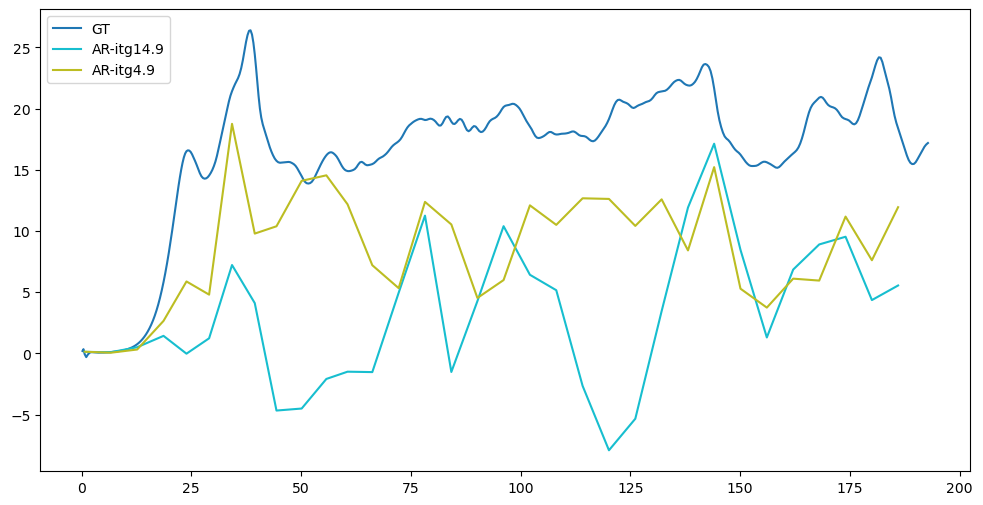

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(time, fluxes, label="GT", c="tab:blue")
# ax.scatter(np.array(list(identity_fluxes.keys())), list(identity_fluxes.values()), label="Identity", c="tab:green")
# ax.scatter(np.array(list(autoreg_fluxes.keys())), list(autoreg_fluxes.values()), c="tab:green", label="Autoregressive")
# ax.scatter(np.array(list(norm_pred_fluxes.keys())), list(norm_pred_fluxes.values()), c="tab:red", label="One-step Re-normalized")
# ax.scatter(np.array(list(pred_fluxes.keys())), list(pred_fluxes.values()), c="tab:green", label="One-step")
ax.plot(
    np.array(list(norm_pred_fluxes.keys())),
    list(norm_pred_fluxes.values()),
    c="tab:cyan",
    label="AR-itg14.9",
)
ax.plot(
    np.array(list(pred_fluxes.keys())),
    list(pred_fluxes.values()),
    c="tab:olive",
    label="AR-itg4.9",
)
# ax.scatter(np.array(list(pred_fluxes.keys())), list(pred_fluxes.values()), c="tab:olive", label="AR")
plt.legend()

Text(0, 0.5, 'Correlation to ground-truth')

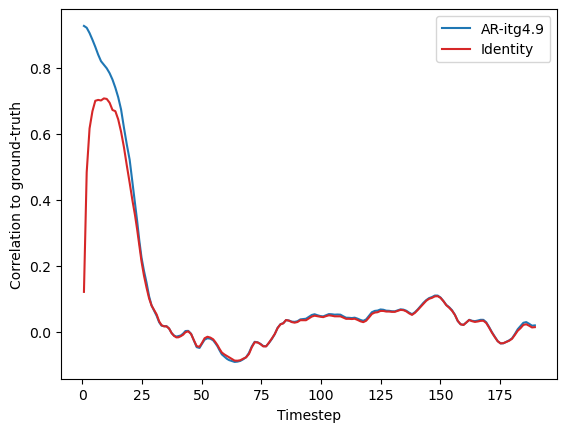

In [14]:
plt.plot(
    [val.cpu().item() for val in model_corr.keys()],
    [val.cpu().item() for val in model_corr.values()],
    c="tab:blue",
    label="AR-itg4.9",
)
plt.plot(
    [val.cpu().item() for val in gt_corr.keys()],
    [val.cpu().item() for val in gt_corr.values()],
    c="tab:red",
    label="Identity",
)
plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Correlation to ground-truth")

In [236]:
k = 51
timeSlice = k
k_file = os.path.join(DUMP_DIR, f"K{str(k).zfill(2)}")
gt_path = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"
poten_file = "Poten00000501"

Text(0, 0.5, '|phi|^{2}')

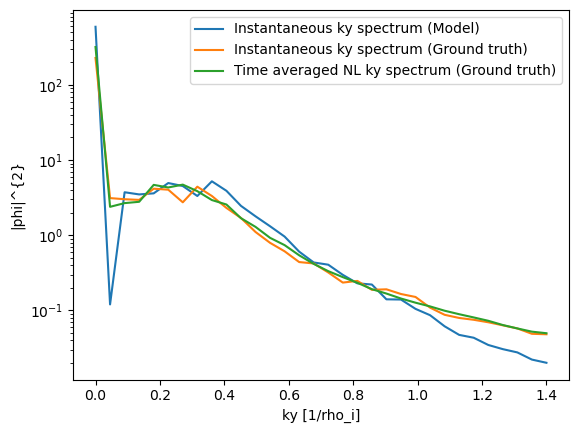

In [237]:
# plotting ky spectra
ky_gt = np.loadtxt(os.path.join(gt_path, "kyspec"))
ky_model = np.loadtxt(os.path.join(k_file, "kyspec"))
ky = np.loadtxt(os.path.join(k_file, "krho"))
plt.semilogy(ky[:, 0], ky_model, label="Instantaneous ky spectrum (Model)")
plt.semilogy(
    ky[:, 0], ky_gt[timeSlice * 3, :], label="Instantaneous ky spectrum (Ground truth)"
)
plt.semilogy(
    ky[:, 0],
    np.mean(ky_gt[:, :], axis=0),
    label="Time averaged NL ky spectrum (Ground truth)",
)
plt.legend()
plt.xlabel("ky [1/rho_i]")
plt.ylabel("|phi|^{2}")

Text(0, 0.5, '|phi|^{2}')

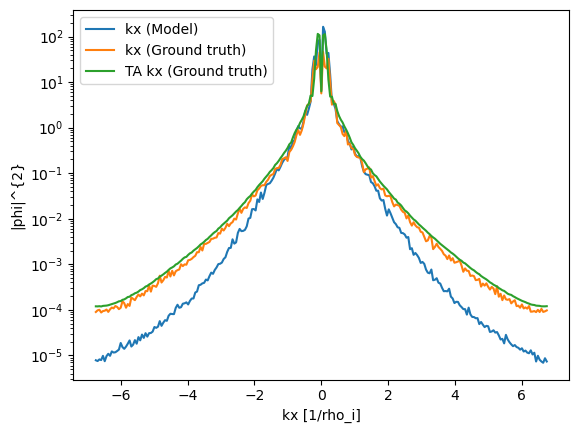

In [238]:
# plotting kx spectra
kx_gt = np.loadtxt(os.path.join(gt_path, "kxspec"))
kx_model = np.loadtxt(os.path.join(k_file, "kxspec"))
kx = np.loadtxt(os.path.join(k_file, "kxrh"))
plt.figure(2)
plt.semilogy(kx[0, :], kx_model, label="kx (Model)")
plt.semilogy(kx[0, :], kx_gt[timeSlice * 3, :], label="kx (Ground truth)")
plt.semilogy(kx[0, :], np.mean(kx_gt[300:, :], axis=0), label="TA kx (Ground truth)")
plt.legend(loc="upper left")
plt.xlabel("kx [1/rho_i]")
plt.ylabel("|phi|^{2}")

Text(0, 0.5, 'Q_{i} [gB]')

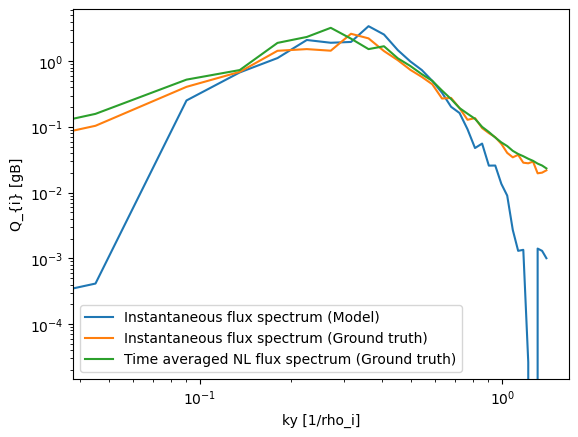

In [239]:
# plotting flux spectra
flux_gt = np.loadtxt(os.path.join(gt_path, "eflux_spectra.dat"))
flux_model = np.loadtxt(os.path.join(k_file, "eflux_spectra.dat"))
ky = np.loadtxt(os.path.join(k_file, "krho"))
plt.loglog(ky[:, 0], flux_model, label="Instantaneous flux spectrum (Model)")
plt.loglog(
    ky[:, 0],
    flux_gt[timeSlice * 3, :],
    label="Instantaneous flux spectrum (Ground truth)",
)
plt.loglog(
    ky[:, 0],
    np.mean(flux_gt[300:, :], axis=0),
    label="Time averaged NL flux spectrum (Ground truth)",
)
plt.legend()
plt.xlabel("ky [1/rho_i]")
plt.ylabel("Q_{i} [gB]")

In [240]:
# plotting potentials and magnitude of zonal flow
xphi = np.loadtxt(os.path.join(gt_path, "xphi"))
sgrid = np.loadtxt(os.path.join(k_file, "sgrid"))
yphi = np.loadtxt(os.path.join(gt_path, "yphi"))
ns = sgrid.shape[0]
nx, ny = xphi.shape[1], xphi.shape[0]

phi_gt = np.loadtxt(os.path.join(gt_path, f"Poten00000{str(k*3).zfill(3)}")).reshape(
    nx, ns, ny, order="F"
)
phi_model = np.loadtxt(os.path.join(k_file, "Poten00000501")).reshape(
    nx, ns, ny, order="F"
)

In [241]:
phi_gt_slice = phi_gt[:, 7, :]
phi_model_slice = phi_model[:, 7, :]
phi_model_ft = fft2(phi_model_slice)
phi_gt_ft = fft2(phi_gt_slice)

fourier_gt_zf = phi_gt_ft.copy()
fourier_gt_turb = phi_gt_ft.copy()
fourier_gt_zf[:, 1:] = 0.0
fourier_gt_turb[:, 0] = 0.0
phi_gt_turb = np.real(ifft2(fourier_gt_turb))
phi_gt_zf = np.real(ifft2(fourier_gt_zf))

fourier_model_zf = phi_model_ft.copy()
fourier_model_turb = phi_model_ft.copy()
fourier_model_zf[:, 1:] = 0.0
fourier_model_turb[:, 0] = 0.0
phi_model_turb = np.real(ifft2(fourier_model_turb))
phi_model_zf = np.real(ifft2(fourier_model_zf))

Text(0.5, 1.0, '$phi$ (No ZF, Ground truth)')

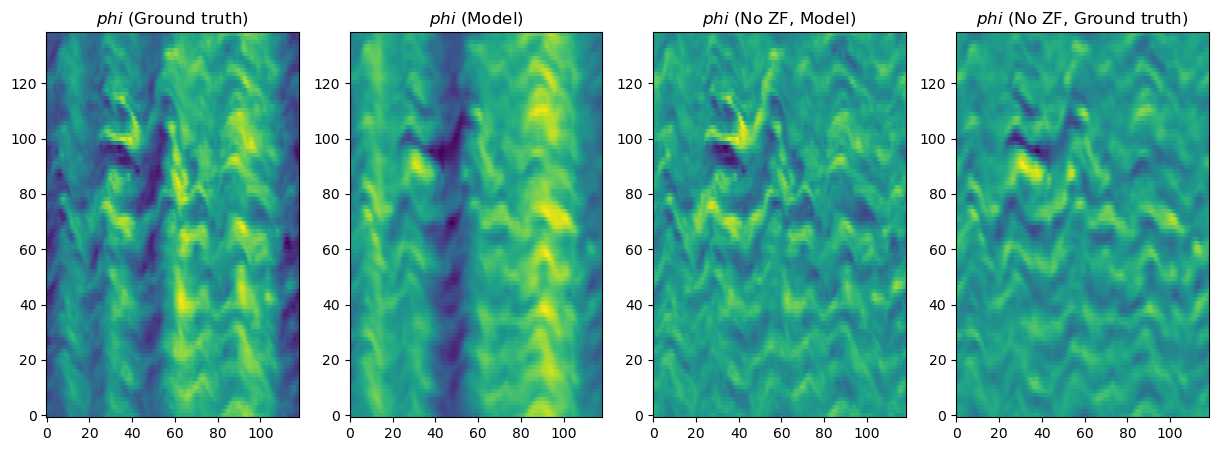

In [242]:
plt.figure(figsize=(15, 5))
plt.axis("off")
plt.subplot(1, 4, 1)
plt.pcolormesh(xphi, yphi, phi_gt[:, 7, :].T)
plt.title("$phi$ (Ground truth)")
plt.subplot(1, 4, 2)
plt.pcolormesh(xphi, yphi, phi_model[:, 7, :].T)
plt.title("$phi$ (Model)")
plt.subplot(1, 4, 3)
plt.pcolormesh(xphi, yphi, phi_gt_turb.T)
plt.title("$phi$ (No ZF, Model)")
plt.subplot(1, 4, 4)
plt.pcolormesh(xphi, yphi, phi_model_turb.T)
plt.title("$phi$ (No ZF, Ground truth)")

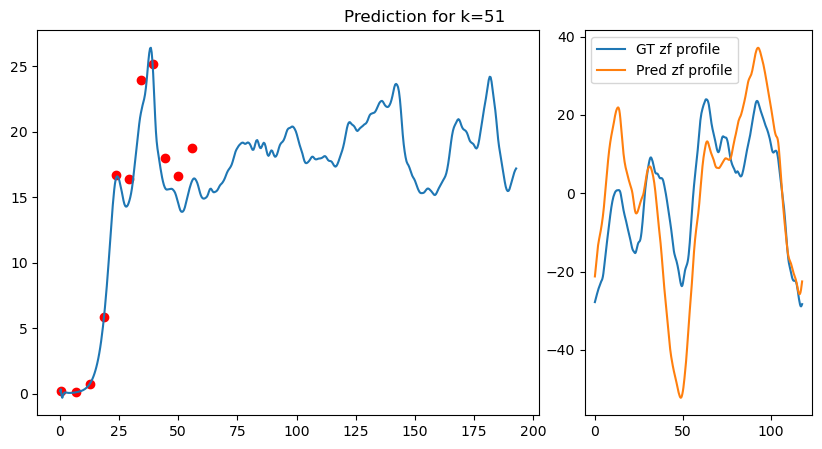

In [243]:
plt.figure(figsize=(10, 5))
plt.title(f"Prediction for k={k}")
plt.axis("off")
plt.subplot(1, 3, (1, 2))
plt.plot(time, fluxes)
plt.scatter(np.array(list(pred_fluxes.keys())), list(pred_fluxes.values()), c="r")
plt.subplot(1, 3, 3)
plt.plot(xphi[0, :], phi_gt_zf[:, 0], label="GT zf profile")
plt.plot(xphi[0, :], phi_model_zf[:, 0], label="Pred zf profile")
plt.legend()

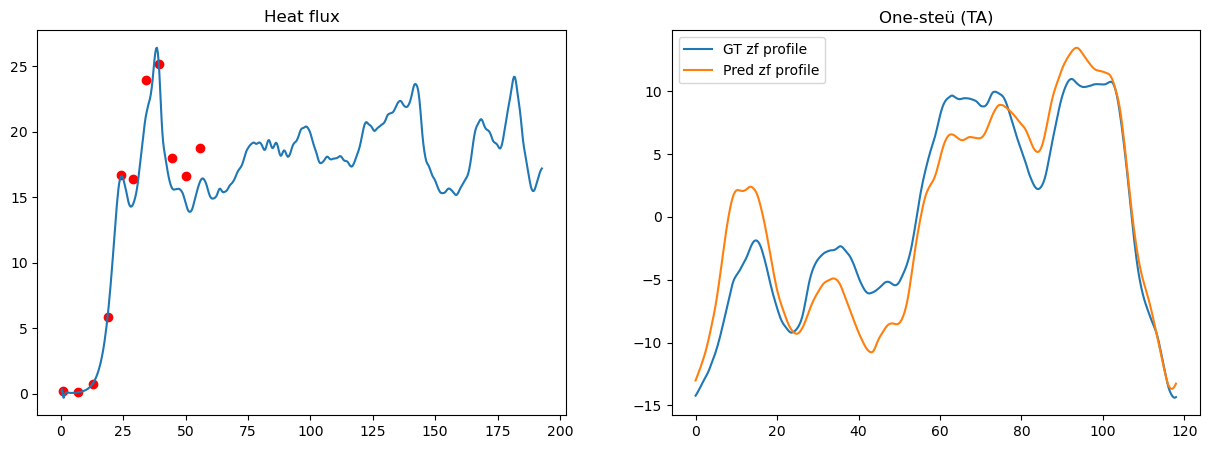

In [244]:
avg_phi_gt_zf = []
avg_phi_model_zf = []
DUMP_DIR = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual_512/20250213_225802/onestep/cyclone4_2_2_ifft_separate/best"

for k in range(1, 52, 5):
    timeSlice = k
    k_file = os.path.join(DUMP_DIR, f"K{str(k).zfill(2)}")
    gt_path = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"
    poten_file = "Poten00000501"

    ky_gt = np.loadtxt(os.path.join(gt_path, "kyspec"))
    ky_model = np.loadtxt(os.path.join(k_file, "kyspec"))
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    kx_gt = np.loadtxt(os.path.join(gt_path, "kxspec"))
    kx_model = np.loadtxt(os.path.join(k_file, "kxspec"))
    kx = np.loadtxt(os.path.join(k_file, "kxrh"))

    flux_gt = np.loadtxt(os.path.join(gt_path, "eflux_spectra.dat"))
    flux_model = np.loadtxt(os.path.join(k_file, "eflux_spectra.dat"))
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    xphi = np.loadtxt(os.path.join(gt_path, "xphi"))
    sgrid = np.loadtxt(os.path.join(k_file, "sgrid"))
    yphi = np.loadtxt(os.path.join(gt_path, "yphi"))
    ns = sgrid.shape[0]
    nx, ny = xphi.shape[1], xphi.shape[0]

    phi_gt = np.loadtxt(
        os.path.join(gt_path, f"Poten00000{str(k*3).zfill(3)}")
    ).reshape(nx, ns, ny, order="F")
    phi_model = np.loadtxt(os.path.join(k_file, "Poten00000501")).reshape(
        nx, ns, ny, order="F"
    )

    phi_gt_slice = phi_gt[:, 7, :]
    phi_model_slice = phi_model[:, 7, :]
    phi_model_ft = fft2(phi_model_slice)
    phi_gt_ft = fft2(phi_gt_slice)

    fourier_gt_zf = phi_gt_ft.copy()
    fourier_gt_turb = phi_gt_ft.copy()
    fourier_gt_zf[:, 1:] = 0.0
    fourier_gt_turb[:, 0] = 0.0
    phi_gt_turb = np.real(ifft2(fourier_gt_turb))
    phi_gt_zf = np.real(ifft2(fourier_gt_zf))

    fourier_model_zf = phi_model_ft.copy()
    fourier_model_turb = phi_model_ft.copy()
    fourier_model_zf[:, 1:] = 0.0
    fourier_model_turb[:, 0] = 0.0
    phi_model_turb = np.real(ifft2(fourier_model_turb))
    phi_model_zf = np.real(ifft2(fourier_model_zf))

    avg_phi_gt_zf.append(phi_gt_zf[:, 0])
    avg_phi_model_zf.append(phi_model_zf[:, 0])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Heat flux")
plt.plot(time, fluxes, c="tab:blue")
plt.scatter(np.array(list(pred_fluxes.keys())), list(pred_fluxes.values()), c="r")
plt.subplot(1, 2, 2)
plt.title("One-step (TA)")
plt.plot(xphi[0, :], np.mean(avg_phi_gt_zf, axis=0), label="GT zf profile")
plt.plot(xphi[0, :], np.mean(avg_phi_model_zf, axis=0), label="Pred zf profile")
plt.legend()

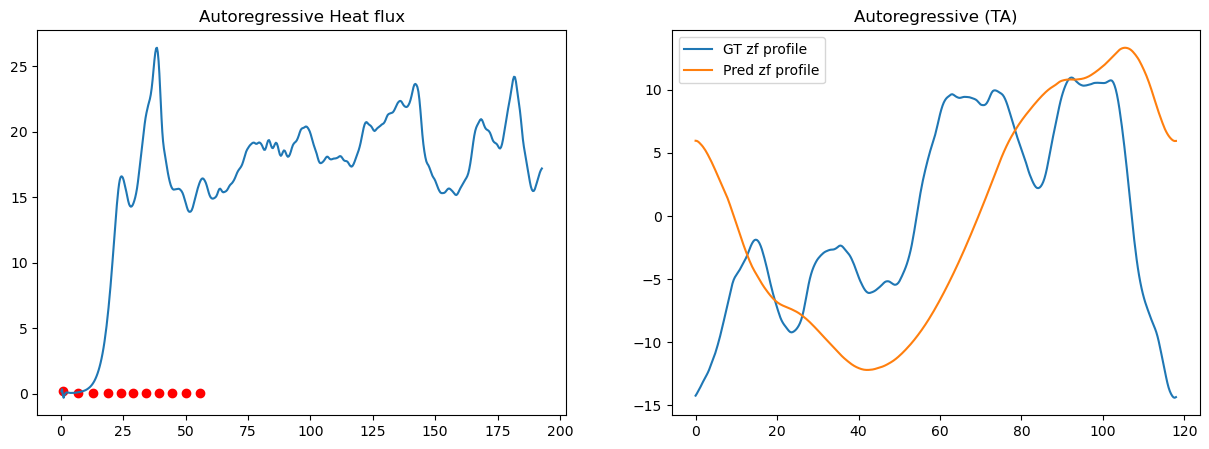

In [57]:
avg_phi_gt_zf = []
avg_phi_model_zf = []
DUMP_DIR = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual/20250212_115023/autoreg_norm/cyclone4_2_2_ifft_separate/best"

for k in range(1, 52, 5):
    timeSlice = k
    k_file = os.path.join(DUMP_DIR, f"K{str(k).zfill(2)}")
    gt_path = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"
    poten_file = "Poten00000501"

    ky_gt = np.loadtxt(os.path.join(gt_path, "kyspec"))
    ky_model = np.loadtxt(os.path.join(k_file, "kyspec"))
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    kx_gt = np.loadtxt(os.path.join(gt_path, "kxspec"))
    kx_model = np.loadtxt(os.path.join(k_file, "kxspec"))
    kx = np.loadtxt(os.path.join(k_file, "kxrh"))

    flux_gt = np.loadtxt(os.path.join(gt_path, "eflux_spectra.dat"))
    flux_model = np.loadtxt(os.path.join(k_file, "eflux_spectra.dat"))
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    xphi = np.loadtxt(os.path.join(gt_path, "xphi"))
    sgrid = np.loadtxt(os.path.join(k_file, "sgrid"))
    yphi = np.loadtxt(os.path.join(gt_path, "yphi"))
    ns = sgrid.shape[0]
    nx, ny = xphi.shape[1], xphi.shape[0]

    phi_gt = np.loadtxt(
        os.path.join(gt_path, f"Poten00000{str(k*3).zfill(3)}")
    ).reshape(nx, ns, ny, order="F")
    phi_model = np.loadtxt(os.path.join(k_file, "Poten00000501")).reshape(
        nx, ns, ny, order="F"
    )

    phi_gt_slice = phi_gt[:, 7, :]
    phi_model_slice = phi_model[:, 7, :]
    phi_model_ft = fft2(phi_model_slice)
    phi_gt_ft = fft2(phi_gt_slice)

    fourier_gt_zf = phi_gt_ft.copy()
    fourier_gt_turb = phi_gt_ft.copy()
    fourier_gt_zf[:, 1:] = 0.0
    fourier_gt_turb[:, 0] = 0.0
    phi_gt_turb = np.real(ifft2(fourier_gt_turb))
    phi_gt_zf = np.real(ifft2(fourier_gt_zf))

    fourier_model_zf = phi_model_ft.copy()
    fourier_model_turb = phi_model_ft.copy()
    fourier_model_zf[:, 1:] = 0.0
    fourier_model_turb[:, 0] = 0.0
    phi_model_turb = np.real(ifft2(fourier_model_turb))
    phi_model_zf = np.real(ifft2(fourier_model_zf))

    avg_phi_gt_zf.append(phi_gt_zf[:, 0])
    avg_phi_model_zf.append(phi_model_zf[:, 0])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("Autoregressive Heat flux")
plt.plot(time, fluxes)
plt.scatter(
    np.array(list(pred_autoreg_fluxes.keys())),
    list(pred_autoreg_fluxes.values()),
    c="r",
)
plt.subplot(1, 2, 2)
plt.title("Autoregressive (TA)")
plt.plot(xphi[0, :], np.mean(avg_phi_gt_zf, axis=0), label="GT zf profile")
plt.plot(xphi[0, :], np.mean(avg_phi_model_zf, axis=0), label="Pred zf profile")
plt.legend()

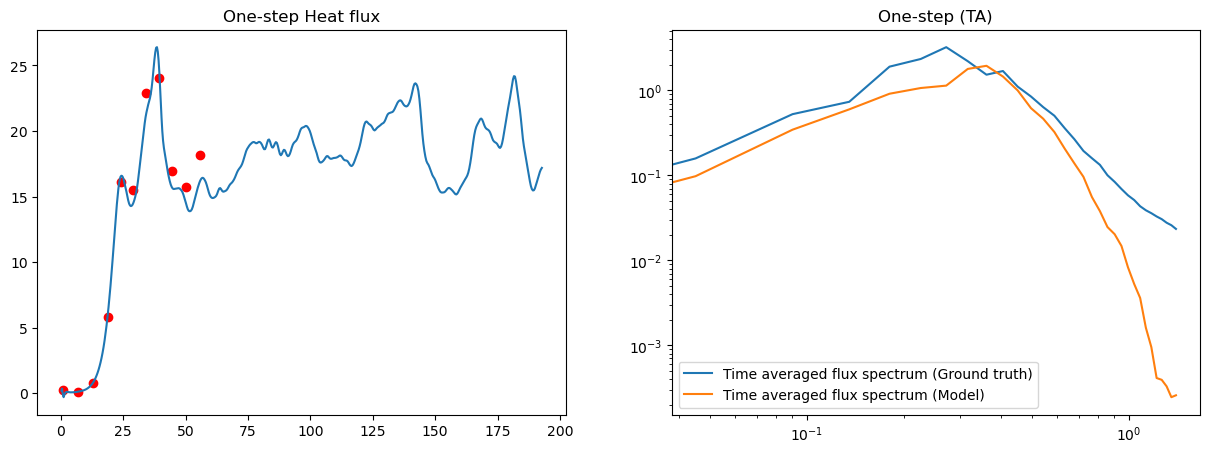

In [71]:
avg_phi_gt_zf = []
avg_phi_model_zf = []
avg_flux_model = []
DUMP_DIR = "/restricteddata/ukaea/checkpoints/separate_zf_first_residual/20250212_115023/onestep_norm/cyclone4_2_2_ifft_separate/best"

for k in range(1, 52, 5):
    timeSlice = k
    k_file = os.path.join(DUMP_DIR, f"K{str(k).zfill(2)}")
    gt_path = "/restricteddata/ukaea/gyrokinetics/raw/cyclone4_2_2/"
    poten_file = "Poten00000501"

    ky_gt = np.loadtxt(os.path.join(gt_path, "kyspec"))
    ky_model = np.loadtxt(os.path.join(k_file, "kyspec"))
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    kx_gt = np.loadtxt(os.path.join(gt_path, "kxspec"))
    kx_model = np.loadtxt(os.path.join(k_file, "kxspec"))
    kx = np.loadtxt(os.path.join(k_file, "kxrh"))

    flux_gt = np.loadtxt(os.path.join(gt_path, "eflux_spectra.dat"))
    flux_model = np.loadtxt(os.path.join(k_file, "eflux_spectra.dat"))
    avg_flux_model.append(flux_model)
    ky = np.loadtxt(os.path.join(k_file, "krho"))

    xphi = np.loadtxt(os.path.join(gt_path, "xphi"))
    sgrid = np.loadtxt(os.path.join(k_file, "sgrid"))
    yphi = np.loadtxt(os.path.join(gt_path, "yphi"))
    ns = sgrid.shape[0]
    nx, ny = xphi.shape[1], xphi.shape[0]

    phi_gt = np.loadtxt(
        os.path.join(gt_path, f"Poten00000{str(k*3).zfill(3)}")
    ).reshape(nx, ns, ny, order="F")
    phi_model = np.loadtxt(os.path.join(k_file, "Poten00000501")).reshape(
        nx, ns, ny, order="F"
    )

    phi_gt_slice = phi_gt[:, 7, :]
    phi_model_slice = phi_model[:, 7, :]
    phi_model_ft = fft2(phi_model_slice)
    phi_gt_ft = fft2(phi_gt_slice)

    fourier_gt_zf = phi_gt_ft.copy()
    fourier_gt_turb = phi_gt_ft.copy()
    fourier_gt_zf[:, 1:] = 0.0
    fourier_gt_turb[:, 0] = 0.0
    phi_gt_turb = np.real(ifft2(fourier_gt_turb))
    phi_gt_zf = np.real(ifft2(fourier_gt_zf))

    fourier_model_zf = phi_model_ft.copy()
    fourier_model_turb = phi_model_ft.copy()
    fourier_model_zf[:, 1:] = 0.0
    fourier_model_turb[:, 0] = 0.0
    phi_model_turb = np.real(ifft2(fourier_model_turb))
    phi_model_zf = np.real(ifft2(fourier_model_zf))

    avg_phi_gt_zf.append(phi_gt_zf[:, 0])
    avg_phi_model_zf.append(phi_model_zf[:, 0])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.title("One-step Heat flux")
plt.plot(time, fluxes)
plt.scatter(np.array(list(pred_fluxes.keys())), list(pred_fluxes.values()), c="r")
plt.subplot(1, 2, 2)
plt.title("One-step (TA)")
flux_gt = np.loadtxt(os.path.join(gt_path, "eflux_spectra.dat"))
ky = np.loadtxt(os.path.join(k_file, "krho"))
plt.loglog(
    ky[:, 0],
    np.mean(flux_gt[300:, :], axis=0),
    label="Time averaged flux spectrum (Ground truth)",
)
plt.loglog(
    ky[:, 0],
    np.mean(avg_flux_model, axis=0),
    label="Time averaged flux spectrum (Model)",
)
plt.legend()